# Day 2 · 06 — RNN & LSTM: guess the next number 📈

So far every model looked at **pictures**. A picture arrives **all at once**.
Some data does not: it comes **one value after another**, and the **order matters**.
Examples: temperature every day, a stock price every minute, steps on a fitness watch every hour.
A list of numbers in time order is called a **sequence** (or **time series**).

**Today's question:** I show you the last **10 numbers** of a wave. What is the **next** number?

**The big idea in one picture:** an **RNN** reads the numbers **one by one**, with a **small whiteboard** next to it.
After every number it **updates the whiteboard** with a short note: "going up… going up faster… slowing down…".
After the last number it looks **only at the whiteboard** and makes its guess.

```
  0.10   0.20   0.29   0.39   ...   0.78
    │      │      │      │            │
    ▼      ▼      ▼      ▼            ▼
 [board]→[board]→[board]→[board]→ … →[board] ──► next number = ?
  (the same reader updates the same small whiteboard after every number)
```

| Step | What we do | Everyday idea |
|---|---|---|
| 1 | make a wave of 1,000 numbers | a temperature curve over 1,000 days |
| 2 | cut it into "10 numbers → next number" examples | flash cards: question on the front, answer on the back |
| 3 | watch an RNN read 4 numbers | the reader and the whiteboard |
| 4 | train an **LSTM** (an RNN with a better whiteboard) | practice on the first 800 days |
| 5 | compare: lazy guess vs plain RNN vs LSTM | is the model better than "tomorrow = today"? |
| 6 | try your own numbers | can you fool it? |

⏱️ Runs in under 1 minute on a laptop CPU. No download needed.
Visual lesson: `Training_Visualized/15_rnn_lstm.html` (RNN & LSTM).

## Step 0 — Setup

**What this cell does:** loads the libraries and fixes the **random seed**.
(A *seed* is the starting point of the computer's dice. Same seed → everybody gets the same numbers.)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(0)                          # same "dice" for everybody
torch.manual_seed(0)
print("torch", torch.__version__, "ready ✔")

torch 2.7.1+cu118 ready ✔


## Step 1 — Make the data

**What this cell does:** makes **1,000 numbers** that go up and down like a wave (a **sine** curve),
and adds a little random **noise** (small wobbles), just like real measurements are never perfectly smooth.
Think of it as the temperature on 1,000 days.

first 10 numbers: [0.18 0.14 0.3  0.52 0.58 0.38 0.66 0.63 0.71 0.82]


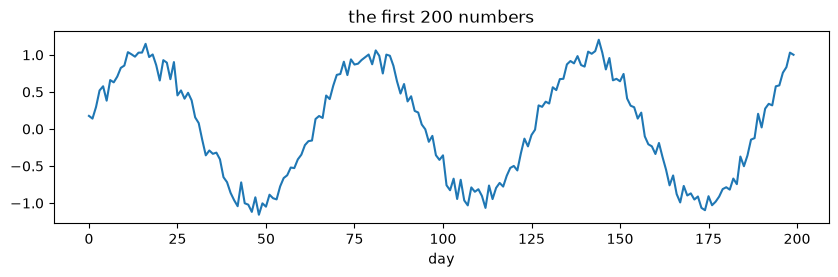

In [2]:
days = np.arange(1000)
wave = np.sin(0.1 * days) + np.random.normal(0, 0.1, 1000)   # smooth wave + small wobbles

print("first 10 numbers:", wave[:10].round(2))
plt.figure(figsize=(10, 2.5))
plt.plot(days[:200], wave[:200])
plt.title("the first 200 numbers"); plt.xlabel("day"); plt.show()

👀 **What to notice:** the numbers go up and down between about -1 and 1, and one full wave takes about **63 days**.
If you know the last few numbers, you can guess roughly where the curve goes next. Can a network learn that?

## Step 2 — Cut the wave into examples

A network learns from **examples**: an input and the right answer. We slide a **window** of 10 numbers along the wave:

```
numbers 0..9   → answer: number 10
numbers 1..10  → answer: number 11
numbers 2..11  → answer: number 12
...
```

**What this cell does:** builds all these examples and shows the first one.

In [3]:
WINDOW = 10

X, y = [], []
for i in range(len(wave) - WINDOW):
    X.append(wave[i : i + WINDOW])        # 10 numbers in a row  (the question)
    y.append(wave[i + WINDOW])            # the number right after (the answer)
X, y = np.array(X), np.array(y)

print("X:", X.shape, "= (examples, numbers per example)")
print("y:", y.shape, "= (one answer per example)\n")
print("example 0 input :", X[0].round(2))
print("example 0 answer:", y[0].round(2))

X: (990, 10) = (examples, numbers per example)
y: (990,) = (one answer per example)

example 0 input : [0.18 0.14 0.3  0.52 0.58 0.38 0.66 0.63 0.71 0.82]
example 0 answer: 0.86


**What this cell does:** turns the examples into **tensors** (PyTorch's tables of numbers) and splits them **by time**:
the first 800 days for **training**, the rest for **testing**.
We do not shuffle before splitting: the test is "predict the **future** you have never seen", just like real forecasting.

An RNN wants every number in its own little box, so the shape becomes `(examples, 10 steps, 1 number per step)`.

In [4]:
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)   # (990, 10)  →  (990, 10, 1)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)   # (990,)     →  (990, 1)

cut = 800 - WINDOW
x_train, y_train = X[:cut], y[:cut]
x_test, y_test = X[cut:], y[cut:]
print("train:", tuple(x_train.shape), "  test:", tuple(x_test.shape))

train: (790, 10, 1)   test: (200, 10, 1)


## Step 3 — Watch an RNN read 4 numbers

Our model has two parts:

```
10 numbers ──► RNN ──────────────────────► Linear ──► next number
               reads them one by one and   looks only at the LAST
               updates its whiteboard      whiteboard and makes the guess
```

* **RNN** = **r**ecurrent **n**eural **n**etwork. "Recurrent" = it does the same thing again and again, once per number.
* The **whiteboard** is officially called the **hidden state**: a few numbers that summarize "what I have read so far".
* At every step: *new whiteboard = mix(this number, old whiteboard)*. The same reader (the same weights) is used every time.

**What this cell does:** builds a tiny **untrained** RNN with a whiteboard of only **3 numbers**,
gives it the sequence `1, 2, 3, 4` and prints the whiteboard after each number.

In [5]:
tiny_rnn = nn.RNN(input_size=1, hidden_size=3, batch_first=True)   # 1 number in, whiteboard of 3 numbers

seq = torch.tensor([[[1.0], [2.0], [3.0], [4.0]]])                 # (1 sequence, 4 steps, 1 number)
boards, last_board = tiny_rnn(seq)

for number, board in zip([1, 2, 3, 4], boards[0]):
    print(f"after reading {number}: whiteboard = {board.detach().numpy().round(2)}")
print("\nlast whiteboard:", last_board.detach().numpy().round(2).ravel(), " ← this goes to the Linear layer")

after reading 1: whiteboard = [-0.49  0.15 -0.35]
after reading 2: whiteboard = [-0.4   0.51 -0.72]
after reading 3: whiteboard = [-0.54  0.78 -0.88]
after reading 4: whiteboard = [-0.56  0.9  -0.96]

last whiteboard: [-0.56  0.9  -0.96]  ← this goes to the Linear layer


👀 **What to notice:** 4 numbers in → 4 whiteboards out (one after each number). Each whiteboard depends on the number **and**
on the whiteboard before it. Only the **last** one is used for the guess. Right now the weights are random; training will teach
the RNN *what* to write on the whiteboard.

### Why an LSTM and not a plain RNN?

A plain RNN **rewrites its whole whiteboard** at every step. After many steps, notes from the start get smudged
and disappear: it **forgets the beginning** of long sequences. (The technical name for this is the **vanishing gradient** problem:
during learning, the signal from early steps becomes too weak to matter.)

An **LSTM** (**L**ong **S**hort-**T**erm **M**emory) is an RNN with a smarter whiteboard. It gets a second, protected
notebook (the **cell state**) and three tools, called **gates**. A gate is a small dial between 0 (closed) and 1 (open) that the network learns:

| Gate | Tool | Question it answers |
|---|---|---|
| 🚪 forget gate | **eraser** | what old notes should I wipe out now? |
| 📥 input gate | **pen** | what from this new number is worth writing down? |
| 📤 output gate | **cover** | which part of my notes should I show to the next layer right now? |

Because notes are only changed through these tools (mostly by **adding**, not rewriting everything), important notes can survive
many more steps. In PyTorch the change is one word: `nn.RNN` → `nn.LSTM`.

## Step 4 — Train an LSTM

**What this cell does:** puts the two parts together into one model. `kind` chooses the reader: `"lstm"`, `"rnn"` or `"gru"`
(a GRU is a lighter LSTM with only two gates).

In [6]:
class Predictor(nn.Module):
    def __init__(self, kind="lstm", hidden=32):
        super().__init__()
        layer = {"lstm": nn.LSTM, "rnn": nn.RNN, "gru": nn.GRU}[kind]
        self.seq = layer(input_size=1, hidden_size=hidden, batch_first=True)   # whiteboard of 32 numbers
        self.out = nn.Linear(hidden, 1)                                        # whiteboard → 1 number

    def forward(self, x):                 # x: (batch, 10, 1)
        boards, _ = self.seq(x)
        return self.out(boards[:, -1])    # only the whiteboard after the LAST number

**What this cell does:** defines `train(kind)`: the usual training loop from Day 1.
The loss is **MSE** (mean squared error: how far off are the guesses, squared). In every **epoch** (one pass over all training
examples) the model sees 32 examples at a time and adjusts itself a little.
At the end we print the **MAE** on the test days: *on average, how far off is the guess?* (smaller = better)

In [7]:
def train(kind, epochs=20):
    torch.manual_seed(0)                               # same start for every model → fair comparison
    model = Predictor(kind)
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        order = torch.randperm(len(x_train))           # shuffle the training examples
        for i in range(0, len(x_train), 32):           # 32 examples at a time
            idx = order[i : i + 32]
            loss = loss_fn(model(x_train[idx]), y_train[idx])
            opt.zero_grad(); loss.backward(); opt.step()

    with torch.no_grad():
        mae = (model(x_test) - y_test).abs().mean().item()
    print(f"{kind.upper():4s}  test MAE = {mae:.3f}")
    return model, mae

**What this cell does:** trains the LSTM for 20 epochs (a few seconds).

In [8]:
lstm, lstm_mae = train("lstm")

LSTM  test MAE = 0.091


**What this cell does:** draws the real numbers of the test days and the LSTM's guesses on top.

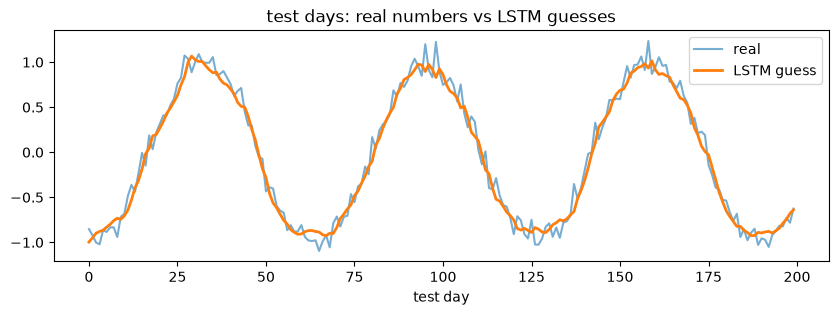

In [9]:
with torch.no_grad():
    guess = lstm(x_test)

plt.figure(figsize=(10, 3))
plt.plot(y_test.numpy(), label="real", alpha=0.6)
plt.plot(guess.numpy(), label="LSTM guess", linewidth=2)
plt.title("test days: real numbers vs LSTM guesses"); plt.xlabel("test day"); plt.legend(); plt.show()

👀 **What to notice:** the test MAE is about **0.09**: on average the guess is off by less than 0.1 (the wave goes from -1 to 1).
The orange line follows the wave closely, but it is **smoother** than the real line.
The small wobbles are random noise: nobody can predict them, so the model learns to ignore them and follows the wave underneath.

## Step 5 — Is the model worth it? Compare

Three contenders on the same test days:

1. 😴 **lazy guess**: "the next number = the last number" (no learning at all)
2. **plain RNN**: same model, same size, same training, but `nn.RNN` instead of `nn.LSTM`
3. **LSTM**: from Step 4

**What this cell does:** computes the lazy guess, trains the plain RNN and puts all three in one bar chart.

LAZY  test MAE = 0.121
RNN   test MAE = 0.096


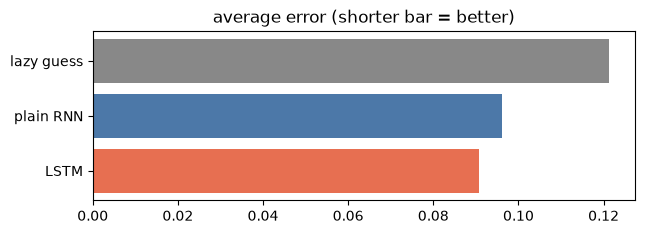

In [ ]:
lazy_mae = (x_test[:, -1] - y_test).abs().mean().item()   # guess = last number of the window
print(f"LAZY  test MAE = {lazy_mae:.3f}")
rnn_model, rnn_mae = train("rnn")

plt.figure(figsize=(7, 2.2))
plt.barh(["lazy guess", "plain RNN", "LSTM"], [lazy_mae, rnn_mae, lstm_mae], color=["#888", "#4c78a8", "#e76f51"])
plt.gca().invert_yaxis(); plt.title("average error (shorter bar = better)"); plt.show()

👀 **What to notice**

* The lazy guess is off by about **0.121** on average. The plain RNN: about **0.096**. The LSTM: about **0.091**.
* Both networks beat the lazy guess: they learned the **shape of the wave**, not just "copy the last number".
* The LSTM is only a little better than the plain RNN here. With only **10 numbers** to remember, a plain whiteboard is almost enough.
  The LSTM's gates (eraser, pen, cover) pay off on **long** sequences (hundreds of steps: long texts, long sensor recordings),
  where a plain RNN forgets the beginning.

## Step 6 — Try your own numbers

**What this cell does:** defines `predict_next(numbers)`: give it any 10 numbers, it returns the LSTM's guess for the 11th.
Change the numbers and run it again!

In [11]:
def predict_next(numbers, model=lstm):
    x = torch.tensor(numbers, dtype=torch.float32).reshape(1, -1, 1)   # (1 sequence, 10 steps, 1 number)
    with torch.no_grad():
        return model(x).item()

tests = {
    "going up      ": [0.0, 0.1, 0.2, 0.3, 0.39, 0.48, 0.56, 0.64, 0.72, 0.78],
    "near the top  ": [0.78, 0.84, 0.89, 0.93, 0.96, 0.98, 0.99, 1.0, 0.99, 0.97],
    "going down    ": [0.5, 0.4, 0.3, 0.2, 0.1, 0.0, -0.1, -0.2, -0.3, -0.39],
    "flat (never seen)": [0.5] * 10,
}
for name, numbers in tests.items():
    print(f"{name}  last = {numbers[-1]:5.2f}   →  next guess = {predict_next(numbers):5.2f}")

going up        last =  0.78   →  next guess =  0.83
near the top    last =  0.97   →  next guess =  0.87
going down      last = -0.39   →  next guess = -0.49
flat (never seen)  last =  0.50   →  next guess =  0.43


👀 **What to notice:** "going up" → it guesses a bit higher; "near the top" → it guesses the curve turns **down**;
"going down" → a bit lower. It learned the shape of the wave.
The flat line never appeared in training, so its guess is odd: a model only knows the patterns it has seen.

## 🎓 What to remember

1. **A sequence** is data where **order matters** (temperature per day, prices per minute, words in a sentence).
2. An **RNN** reads it one step at a time and keeps a small **whiteboard** (the hidden state) of what it has read so far.
3. Recipe: **sequence → cut into windows (10 numbers → next number) → RNN/LSTM → Linear on the last whiteboard → guess**.
4. A plain RNN **forgets** early steps. An **LSTM** has an **eraser, a pen and a cover** (forget, input, output gates), so it remembers longer. In code: `nn.RNN` → `nn.LSTM`.
5. Always compare with a **lazy baseline** ("next = last"). A model is only useful if it beats it.
6. The same idea works for **text**: words are turned into numbers first, then an RNN/LSTM reads them one by one.

## ✍️ Try it yourself

**Exercise 1 — a lighter LSTM.** Train a **GRU** (an LSTM with only 2 gates) with one line. Is its error closer to the RNN or to the LSTM?

In [12]:
# your code here

<details><summary>Answer</summary>

```python
gru_model, gru_mae = train("gru")
```

The GRU gets a test MAE of about **0.095**: between the LSTM (0.091) and the plain RNN (0.096), and all three are close.
For a short window of 10 numbers, 2 gates are plenty.

</details>

**Exercise 2 — a smaller window.** What if the model only sees the last **3 numbers**? Set `WINDOW = 3`, re-run Step 2 and train the LSTM again.
Does the error go up or down? (Afterwards set `WINDOW = 10` and re-run from Step 2.)

In [13]:
# your code here

<details><summary>Answer</summary>

```python
WINDOW = 3
# re-run the two cells of Step 2, then:
short_lstm, short_mae = train("lstm")
```

The error goes **up**, from about **0.091** to about **0.122**, no better than the lazy guess (0.121).
With only 3 wobbly numbers the model cannot see the shape of the wave: is it going up, or was that just noise?
Seeing more of the past helps.

Don't forget: set `WINDOW = 10` again and re-run from Step 2.

</details>

**Exercise 3 — more wobble.** Make the noise 3× bigger: in Step 1 change `0.1` to `0.3`, then re-run everything up to Step 5.
Does the LSTM still beat the lazy guess? By more or by less? (Afterwards change it back to `0.1`.)

In [14]:
# your code here

<details><summary>Answer</summary>

With noise `0.3` the LSTM's error is about **0.245** and the lazy guess about **0.330**.
Both errors are bigger (the wobbles are bigger and nobody can predict them), but the LSTM now beats the lazy guess by **more**:
copying the last number also copies its big wobble, while the LSTM looks at all 10 numbers and follows the smooth wave underneath.

Don't forget: change the noise back to `0.1` and re-run.

</details>